In [1]:
import numpy as np
import NCrystal as NC
import NCrystal.cifutils
import NCrystal.ncmat2endf

Step 1: Create base `ncmat` model from `cif` information.

In [2]:
cifsrc = NC.cifutils.CIFSource('ni.cif')
c_ni = NC.NCMATComposer.from_cif(cifsrc)

Loading data from file ni.cif
Attempting to load CIF data with gemmi
Self-consistency of structure was verified by spglib


Step 2: Replace dynamic information with VDOS.

In [3]:
vdos_data = np.loadtxt('ni.dat')
c_ni.set_dyninfo_vdos(c_ni.find_label('Ni'), vdos_egrid=vdos_data[:,0], vdos=vdos_data[:,1])

Step 3: Export `ncmat` file and convert to `ENDF-6` format.

In [4]:
a = c_ni.write('ni.ncmat')
res = NC.ncmat2endf.ncmat2endf('ni.ncmat;temp=293.6K', material_name='Ni-metal', elastic_mode='mixed', force=True)

Initialise nuclear data...
Write ENDF file tsl_Ni_in_Ni-metal.endf ...
Files created:
  tsl_Ni_in_Ni-metal.endf : Ni with fraction 1
Suggested material density: 9.288313838 g/cm^3


In [5]:
from ncrystal_notebook_utilities.endf2ace import convert_endf_tsl_to_ace

In [6]:
for _ in res['files']:
    print(_['file'])
    convert_endf_tsl_to_ace(_['file'], ace_filename=_['file'].replace('endf', 'ace'))

tsl_Ni_in_Ni-metal.endf


In [7]:
import openmc 
E = np.geomspace(1e-4,2,1000)
ace_xs_scatt = np.zeros(np.shape(E))
for _ in res['files']:
    data = openmc.data.ThermalScattering.from_ace(_['file'].replace('endf', 'ace'))
    ace_xs_el = data.elastic.xs['294K'](E)
    ace_xs_inel = data.inelastic.xs['294K'](E)
    ace_xs_scatt += _['fraction']*(ace_xs_el+ace_xs_inel)

/home/marquezj/anaconda3/envs/openmc_ncrystal_0153/lib/python3.13/site-packages/openmc/data/thermal.py:202: UserWarning: Thermal scattering material "28000" is not recognized. Assigning a name of c_para_H.
  warn('Thermal scattering material "{}" is not recognized. '


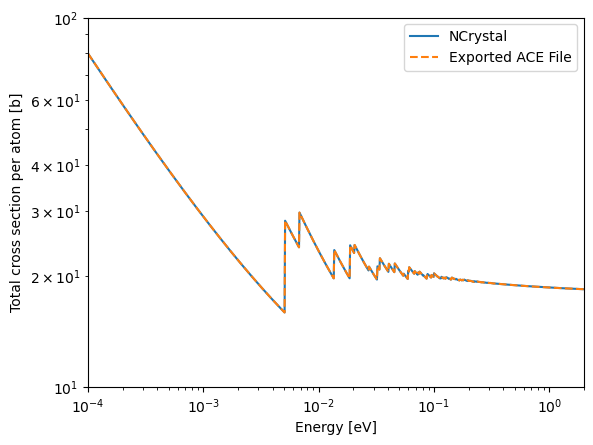

In [8]:
import matplotlib.pyplot as plt
m_ni = NC.load('ni.ncmat')
a = plt.loglog(E, m_ni.scatter.xsect(E)+m_ni.absorption.xsect(E), label='NCrystal')
plt.semilogx(E, ace_xs_scatt+m_ni.absorption.xsect(E), '--', label='Exported ACE File')
a = plt.legend()
a = plt.xlim(1e-4,2)
a = plt.ylim(10,100)
a = plt.xlabel('Energy [eV]')
a = plt.ylabel('Total cross section per atom [b]')